# 03 · Results and the next decision

**Decision:** Feature research is complete for the declared four-policy scope. The fixed route has now passed development validation: calibrate the seven-family model for familiar policies; retain the raw centroid for unseen policies. The final artifacts are fitted on development only. The frozen candidate has now passed all 12 protected acceptance checks on 43,509 rows. Offline product integration and release remain unfinished.

This short notebook is the employer review path: the measured improvement, the failed alternatives, the remaining limitation and the concrete release gates.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Historical references: 2,029 rows, two policies; expanded research is a separate cohort.")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Historical references: 2,029 rows, two policies; expanded research is a separate cohort.
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from build_release_report import display_boundary
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence
from jigsaw_rules.released import released_evidence
from jigsaw_rules.expanded import expanded_evidence
from jigsaw_rules.retrieval import retrieval_evidence
from jigsaw_rules.resolution import resolution_evidence
from jigsaw_rules.formatting import formatting_evidence
from jigsaw_rules.feature_decision import decision_evidence
from build_expanded_report import display_figure as display_expanded
from build_formatting_report import display_figure as display_formatting

expanded = expanded_evidence(root)
retrieval = retrieval_evidence(root)
resolution = resolution_evidence(root)
formatting = formatting_evidence(root)
decision = decision_evidence(root)
assert expanded is not None and retrieval is not None and resolution is not None
assert formatting is not None and decision is not None
controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
released = released_evidence(root)
assert released is not None
print("Verified expanded study:", expanded["metadata"]["run_id"])


Verified expanded study: a57bb74350fcbcd66592


## Protected confirmation: all 12 fixed checks pass
Predictions were frozen in published commit `530ad79929012e807cb42a5253f7b92b090682ec` before eligible target access on September 9, 2026. The primary six-policy macro AUC improves from **0.6801 to 0.7770**, a **+0.0969** gain with paired 95% interval **[0.0898, 0.1051]**. Familiar-policy AUC reaches **0.8276** and unseen-policy AUC **0.6757**; every policy improves.

Overall log loss falls from 0.6685 to 0.5121, and Brier from 0.2360 to 0.1739. This is one fixed post-competition comparison on **43,509 rows**, including two policies wholly excluded from development. The interval conditions on six observed policies. No candidate was retuned on these targets; this is not a Kaggle score. [Frozen protocol and recovery](../docs/CONFIRMATION.md).

Protected decision: accepted


sufficient_policy_class_counts    True
minimum_macro_auc_gain            True
positive_primary_interval         True
maximum_policy_auc_drop           True
positive_familiar_gain            True
positive_unseen_gain              True
all_log_loss_guard                True
familiar_log_loss_guard           True
unseen_log_loss_guard             True
all_brier_guard                   True
familiar_brier_guard              True
unseen_brier_guard                True
Name: Passed preregistered check, dtype: bool

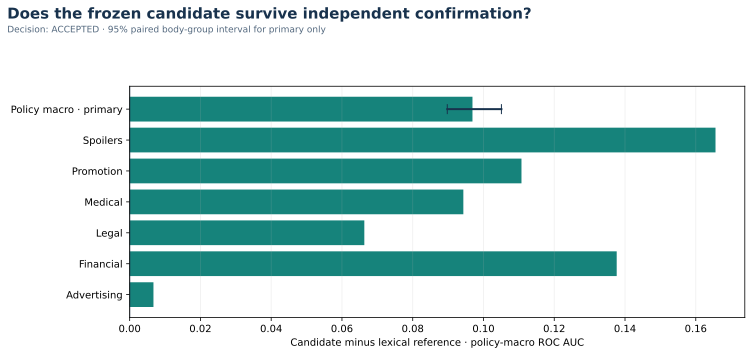

In [3]:
from jigsaw_rules.confirmation_report import confirmation_evidence
from build_protected_report import display_figure as display_protected
protected = confirmation_evidence(root)
assert protected is not None
print("Protected decision:", protected["results"]["status"])
display(pd.Series(protected["results"]["checks"], name="Passed preregistered check"))
display_protected(root, "policy_gains")

## What the expanded research measured
Thirty-four fixed trained configurations share seven purged splits. The feature study adds/removes major families, checks full versus screened representations, and tests training-only NB/SVD controls. Frozen semantic scores are untrained comparison baselines. The 43,576-row reserve remains outside model selection.

The frozen semantic centroid reaches **0.7042 transfer AUC**, versus **0.4728** for the matched lexical reference. Its log loss improves from 0.8126 to 0.6237. Most of the gain comes from avoiding reversed lexical ranking on illegal-activity promotion; legal and medical advice remain difficult. The all-transfer model reaches 0.7989 on familiar policies but only 0.5515 on transfer.

Policy-macro AUC is the primary competition-oriented metric. These are post-competition development results, not a Kaggle score.

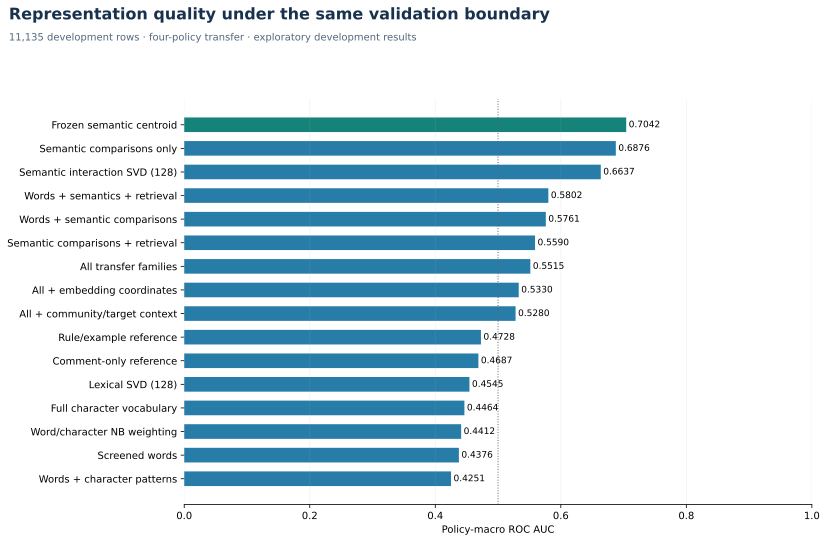

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
7,centroid_intent_mean (rejected),Held-out rule,0.7086,0.6549,0.2320,0.7039
1,qwen_centroid,Held-out rule,0.7042,0.6237,0.2177,0.7559
6,semantic_intent,Held-out rule,0.6909,0.7495,0.2682,0.6206
3,semantic_scalar_only,Held-out rule,0.6876,0.6891,0.2456,0.6872
5,asymmetric_centroid,Held-out rule,0.6865,0.6214,0.2170,0.7554
4,word_semantic_scalar,Held-out rule,0.5761,0.8156,0.2969,0.5727
0,all_transfer,Held-out rule,0.5515,1.4700,0.4503,0.5057
2,rule_examples,Held-out rule,0.4728,0.8126,0.2992,0.5294


In [4]:
display_expanded(root, "comparison")
selected = {"rule_examples", "word_semantic_scalar", "semantic_scalar_only", "qwen_centroid", "all_transfer"}
rows = [r for r in expanded["results"] if r["model"] in selected]
rows += [r for r in formatting["results"] if r["model"] in {"asymmetric_centroid", "semantic_intent"}]
rows += [{"model": "centroid_intent_mean (rejected)", "protocol": "heldout_rule", "metrics": decision["fusion"]["metrics"]}]
display(metric_table(rows, heldout=True).sort_values("Rule macro AUC", ascending=False))

## What would count as a feature improvement?
The family-ablation figure in notebook `02` measures additions to the same screened-word control. The table below compares each representation with the same-fold rule/example reference. A higher point estimate with an interval crossing zero remains an uncertain development observation. Probability losses and policy-level failures are part of the decision. Simultaneous intervals apply within each preregistered study; combining rows below does not create one joint correction over all research.

In [5]:
contrasts = pd.DataFrame(expanded["uncertainty"] + retrieval["uncertainty"])
compared = contrasts[(contrasts.protocol == "heldout_rule") & (contrasts.reference == "rule_examples")]
display(compared.sort_values("observed_delta", ascending=False).head(10)[["candidate", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

,candidate,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
73,qwen_centroid,0.2314,0.1985,0.2600,0.1889,0.2740
76,qwen_kernel_0.2,0.2208,0.1879,0.2488,0.1782,0.2633
77,qwen_kernel_0.5,0.2206,0.1875,0.2487,0.1780,0.2631
75,qwen_kernel_0.1,0.2202,0.1872,0.2484,0.1776,0.2627
79,qwen_mean,0.2200,0.1867,0.2481,0.1775,0.2626
74,qwen_kernel_0.05,0.2180,0.1846,0.2456,0.1755,0.2606
82,semantic_scalar_only,0.2149,0.1802,0.2428,0.1723,0.2574
78,qwen_maximum,0.2122,0.1789,0.2404,0.1696,0.2547
71,latent_qwen_interaction,0.1909,0.1527,0.2222,0.1484,0.2335
83,without_character,0.1183,0.0835,0.1532,0.0757,0.1608


## Why the feature phase can close, and the product cannot
The campaign covers 188,595–188,598 candidate columns per fold and 323 fixed fits. Training screens retain 9,281–9,660 columns across separate banks. The strongest transfer representation is simpler than those banks: a frozen support-centroid comparison. The last semantic variants fail the declared acceptance rule. A fixed average has the highest point AUC (0.7086), but its gain is uncertain and probability/policy regressions fail all five checks. The stopping decision retains 0.7042, rather than selecting the largest reported number.

The fixed route now has executed development evidence. Nine nested inner fits isolate calibration from outer validation labels; all three reconstructed familiar models reproduce their saved predictions within 1.2e-16. Familiar calibration passes all six gates; unseen calibration fails four and is discarded. One candidate and one lexical reference are fitted on all 11,135 development rows. The exact candidate/reference and acceptance protocol were committed before protected scoring; prediction hashes were published before eligible labels were interpreted.

The standalone inference notebook still uses the named lexical reference. Accepted artifacts must be connected to offline inference with parity, latency/memory and missing-support tests. A small example-driven demo, model/data cards and clean-environment release complete the product. [Next milestone specification](../docs/FINAL_MODEL_PLAN.md).

In [6]:
print("Expanded study:", gate["expanded_development"])
print("Feature gate:", gate["status"])
print("Final training justified:", gate["final_training_authorized_by_evidence"])

Expanded study: {'rows': 11135, 'policies': 4, 'fitted_models': 260}
Feature gate: ready_for_final_model_validation
Final training justified: True


## From features to the fitted candidate
The final familiar pipeline retains **9,263 of 181,958 columns** across seven selected families. It contains no target encodings, community metadata or raw embedding coordinates. Unknown policies bypass this learned pipeline.

Nested calibration improves familiar-policy log loss from **0.4761 to 0.4689**; the paired 97.5% interval for improvement is **[0.0037, 0.0109]**. AUC stays near 0.799. Calibrating the centroid damages transfer log loss from **0.6237 to 0.6976**, so unseen-policy probabilities retain their original mapping. This is a calibration result, separate from feature-engineering gains. [Protocol and full results](../docs/MODEL_VALIDATION.md).

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,reference,Familiar rules,0.7311,0.5895,0.2029,0.7692
1,raw,Familiar rules,0.7989,0.4761,0.1569,0.8853
2,calibrated,Familiar rules,0.7991,0.4689,0.1550,0.8846
3,reference,Held-out rule,0.4728,0.8126,0.2992,0.5294
4,raw,Held-out rule,0.7042,0.6237,0.2177,0.7559
5,calibrated,Held-out rule,0.7042,0.6976,0.2479,0.6404


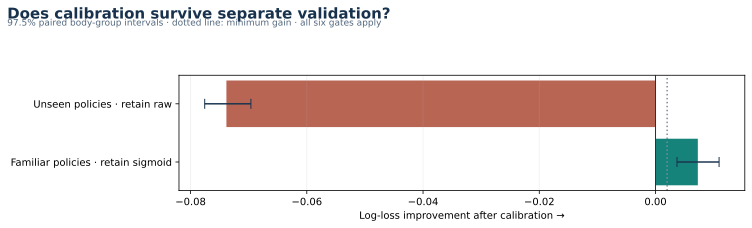

Final selected columns: 9263
Reserved targets accessed during development fitting: False


In [7]:
from jigsaw_rules.model_validation import validation_evidence
from build_model_report import display_figure as display_model
model_validation = validation_evidence(root)
assert model_validation is not None
display(metric_table(model_validation["results"]))
display_model(root, "calibration")
print("Final selected columns:", model_validation["audit"]["final_artifact"]["selected_features"])
print("Reserved targets accessed during development fitting:", model_validation["audit"]["confirmation_targets_accessed"])

## Explore the reasoning
[02 · Research methods, screening and ablations](02_baseline_and_review.ipynb) · [04 · Per-policy and probability diagnostics](04_semantic_benchmark.ipynb) · [01 · Leakage boundaries](01_data_and_validation.ipynb) · [Remaining release milestones](../docs/ROADMAP.md).

The historical two-policy search is preserved in the [research record](../docs/FEATURE_RESEARCH.md); its scores are not compared numerically with this larger cohort as if only the features had changed.